# Trying to apply fpp3 knowledge to this HFT thingie

### Importing packages

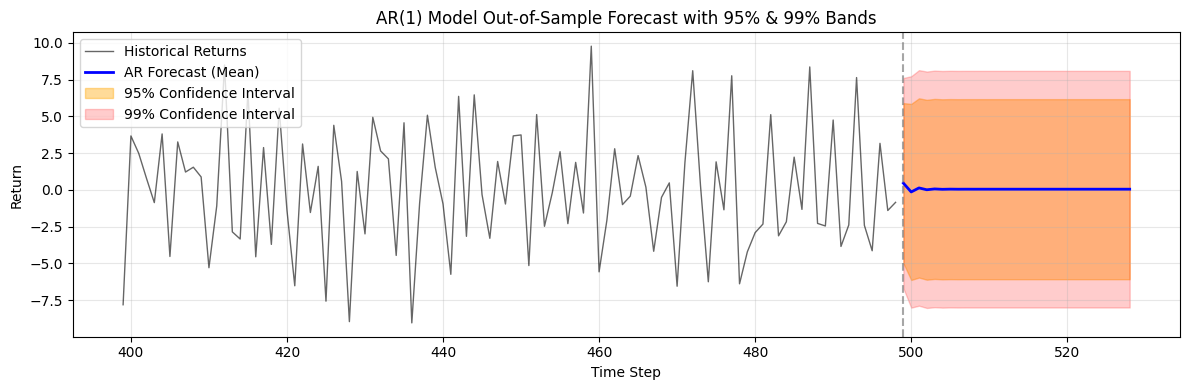

In [56]:
import numpy as np
import pandas as pd
from statsmodels.tsa.ar_model import AutoReg
import matplotlib.pyplot as plt

# ==========================================
# 1. GENERATE SYNTHETIC DATA (Same as before)
# ==========================================
np.random.seed(42)
t = np.arange(500)

trend = 0.05 * t
seasonality = 5 * np.sin(2 * np.pi * t / 50) 
noise = np.concatenate([np.random.normal(0, 1.0, 250), np.random.normal(0, 3.0, 250)])
price = 100 + trend + seasonality + noise

returns = np.diff(price) 

# ==========================================
# 2. FIT THE AR(1) MODEL
# ==========================================
ar_model = AutoReg(returns, lags=1).fit()

# ==========================================
# 3. GET FORECAST AND CONFIDENCE INTERVALS
# ==========================================
forecast_steps = 30
start_idx = len(returns)
end_idx = start_idx + forecast_steps - 1

# statsmodels' get_prediction() is perfect for this. 
# It returns an object containing the mean forecast and confidence intervals.
predictions = ar_model.get_prediction(start=start_idx, end=end_idx)

mean_forecast = predictions.predicted_mean

# Extract the bands (alpha=0.05 for 95%, alpha=0.01 for 99%)
ci_95 = predictions.conf_int(alpha=0.05)
ci_99 = predictions.conf_int(alpha=0.01)

# ==========================================
# 4. PLOT THE RESULTS (CORRECTED)
# ==========================================
plt.figure(figsize=(12, 4))

# Dynamically grab the last 100 steps of actual historical returns
hist_length = 100
start_hist = len(returns) - hist_length

hist_index = np.arange(start_hist, len(returns))
plt.plot(hist_index, returns[-hist_length:], label='Historical Returns', color='black', alpha=0.6, linewidth=1)

# Set up the future time steps x-axis starting exactly where history ends
future_index = np.arange(len(returns), len(returns) + forecast_steps)

# Plot the Predicted Mean
plt.plot(future_index, mean_forecast, label='AR Forecast (Mean)', color='blue', linewidth=2)

# Plot 95% Bands 
plt.fill_between(future_index, ci_95[:, 0], ci_95[:, 1], 
                 color='orange', alpha=0.4, label='95% Confidence Interval')

# Plot 99% Bands
plt.fill_between(future_index, ci_99[:, 0], ci_99[:, 1], 
                 color='red', alpha=0.2, label='99% Confidence Interval')

# Formatting
plt.title('AR(1) Model Out-of-Sample Forecast with 95% & 99% Bands')
plt.xlabel('Time Step')
plt.ylabel('Return')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.axvline(x=len(returns), color='grey', linestyle='--', alpha=0.7) # Mark where forecast begins
plt.tight_layout()

# Show the plot
plt.show()

In [57]:
print("GARCH model")

garch_model = arch_model(returns, mean='Zero', vol='Garch', p=1, q=1)
garch_res = garch_model.fit(disp='off')

sigma = garch_res.conditional_volatility
band_95 = 1.96 * sigma
band_99 = 2.58 * sigma

garch_forecast = garch_res.forecast(horizon=5)

print(f"next 5 forecasted 'variances': \n{garch_forecast.variance.iloc[-1]}")

GARCH model
next 5 forecasted 'variances': 
h.1    15.829579
h.2    15.874940
h.3    15.920301
h.4    15.965662
h.5    16.011023
Name: 498, dtype: float64


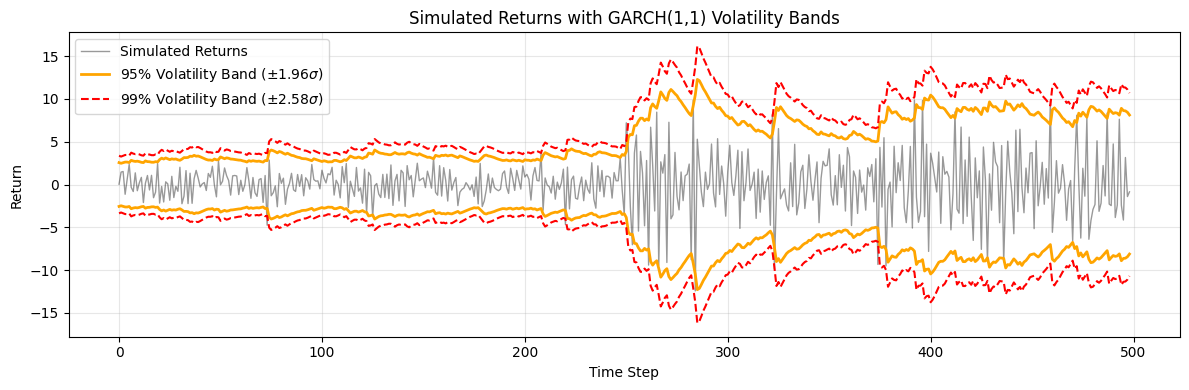

In [58]:
plt.figure(figsize=(12, 4))

# Plot the raw returns
plt.plot(returns, color='black', alpha=0.4, label='Simulated Returns', linewidth=1)

# Plot the 95% Volatility Bands
plt.plot(band_95, color='orange', label='95% Volatility Band ($\pm 1.96\sigma$)', linewidth=2)
plt.plot(-band_95, color='orange', linewidth=2)

# Plot the 99% Volatility Bands
plt.plot(band_99, color='red', linestyle='--', label='99% Volatility Band ($\pm 2.58\sigma$)', linewidth=1.5)
plt.plot(-band_99, color='red', linestyle='--', linewidth=1.5)

# Formatting
plt.title('Simulated Returns with GARCH(1,1) Volatility Bands')
plt.xlabel('Time Step')
plt.ylabel('Return')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

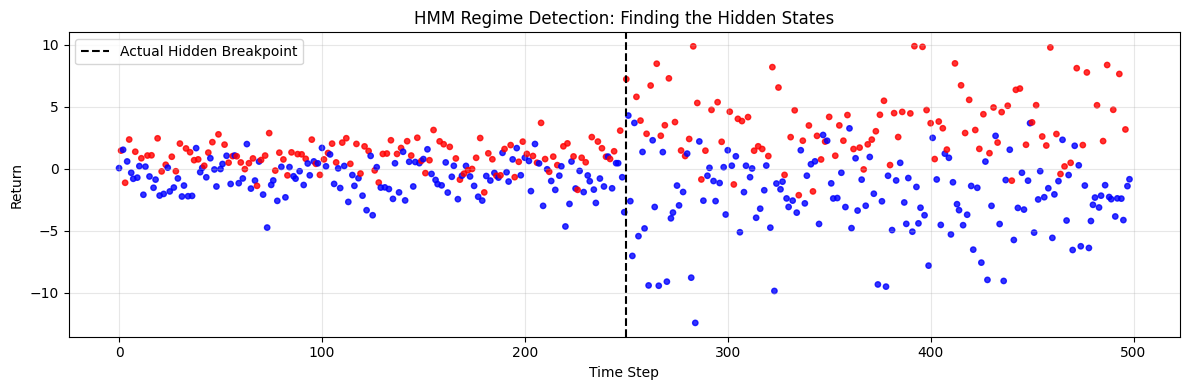

Transition Matrix:
[[4.13569505e-01 5.86430495e-01]
 [9.99999488e-01 5.11902286e-07]]


In [59]:
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm

# 1. RECREATE OUR DATA (Same as before)
np.random.seed(42)
t = np.arange(500)
trend = 0.05 * t
seasonality = 5 * np.sin(2 * np.pi * t / 50) 
noise = np.concatenate([np.random.normal(0, 1.0, 250), np.random.normal(0, 3.0, 250)])
price = 100 + trend + seasonality + noise
returns = np.diff(price)

# 2. PREP DATA FOR HMMLEARN
# hmmlearn expects a 2D array for features (even if it's just 1 column of returns)
X = returns.reshape(-1, 1)

# 3. BUILD AND TRAIN THE HMM
# We assume 2 Hidden States (Gaussian distributions)
model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=100, random_state=42)

# Fit the model (This uses the Baum-Welch algorithm to find the probabilities)
model.fit(X)

# Predict the hidden states (This uses the Viterbi algorithm)
hidden_states = model.predict(X)

# 4. PLOT THE DISCOVERY
plt.figure(figsize=(12, 4))

# We will plot the returns, but color them based on the regime the HMM guessed
colors = ['blue' if state == 0 else 'red' for state in hidden_states]

plt.scatter(np.arange(len(returns)), returns, c=colors, s=15, alpha=0.8)
plt.axvline(x=250, color='black', linestyle='--', label='Actual Hidden Breakpoint')

plt.title('HMM Regime Detection: Finding the Hidden States')
plt.xlabel('Time Step')
plt.ylabel('Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. PRINT THE TRANSITION MATRIX
print("Transition Matrix:")
print(model.transmat_)